In [1]:
import pandas as pd
import importlib
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    'D:\\Программы\\Karpov.Courses - Аналитик данных (2022)\\Часть 1\\Задания\\Данные для Минипроектов\\3_user_data.csv',
)

In [3]:
df1 = pd.read_csv(
    'D:\\Программы\\Karpov.Courses - Аналитик данных (2022)\\Часть 1\\Задания\\Данные для Минипроектов\\3_logs.csv',
)

In [4]:
df1

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629
...,...,...,...,...
4495,64496,False,computer,1585459072
4496,73299,True,phone,1585458370
4497,8967,True,phone,1585465121
4498,52880,False,phone,1585455362


In [5]:
uniq = df1.platform.unique()
df1['platform'].value_counts()

platform
phone       2753
computer    1505
tablet       242
Name: count, dtype: int64

In [6]:
x = df1.query('success == True')\
    .groupby('client')\
    .size()\
    .sort_values(ascending=False)\
    .head()

# количество клиентов у кого больше тру

In [7]:
x_df = x.reset_index()
x_df.columns = ['client', 'success_count']

In [8]:
x_df

,client,success_count
0,36165,41
1,28719,41
2,12179,41
3,52870,41
4,61468,41


In [9]:
df1

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629
...,...,...,...,...
4495,64496,False,computer,1585459072
4496,73299,True,phone,1585458370
4497,8967,True,phone,1585465121
4498,52880,False,phone,1585455362


In [10]:
y = df1.query('success == True')\
    .groupby('platform')\
    .size()
y_df = y.reset_index()
y_df.columns = ['platform', 'success_count']
y_df
# с какого устройства заказывают чаще

,platform,success_count
0,computer,1090
1,phone,2019
2,tablet,180


In [11]:
display(df1)
display(df)

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629
...,...,...,...,...
4495,64496,False,computer,1585459072
4496,73299,True,phone,1585458370
4497,8967,True,phone,1585465121
4498,52880,False,phone,1585455362


,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49
...,...,...,...
2949,19411,False,29
2950,61579,False,50
2951,61221,True,64
2952,29863,False,46


In [12]:
premium_client = df1.merge(df, on='client')
premium_client.query('premium == True')\
    .platform.value_counts()\
    .idxmax()

'phone'

In [13]:
premium_client


,client,success,platform,time,premium,age
0,61468,True,phone,1585425658,False,25
1,35604,False,phone,1585459894,True,65
2,10931,True,computer,1585468629,False,28
3,41928,True,phone,1585446772,False,46
4,48925,True,phone,1585467880,False,33
...,...,...,...,...,...,...
3434,92584,True,computer,1585408896,False,28
3435,95152,True,computer,1585420263,False,67
3436,64496,False,computer,1585459072,False,66
3437,8967,True,phone,1585465121,False,33


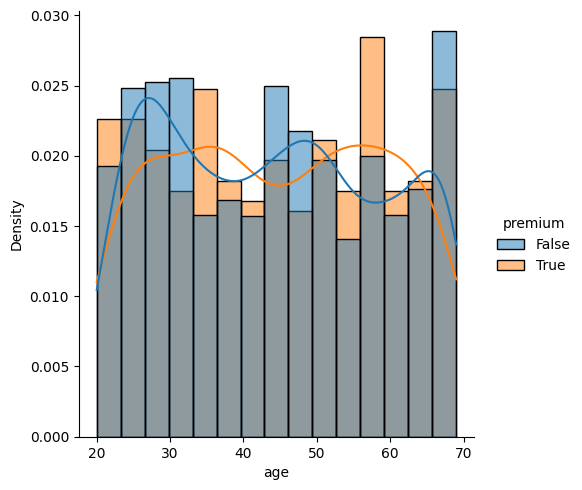

In [21]:
premium_client
ax = sns.displot(x='age', hue='premium', data=premium_client, kind='hist', kde=True, stat='density', common_norm=False)

In [29]:
success_count = premium_client.query('success == True')\
    .client.value_counts()
success_count

client
28719    41
78349    41
92584    41
36165    41
52870    41
         ..
92503     1
53978     1
93566     1
65128     1
83888     1
Name: count, Length: 2104, dtype: int64

<Axes: xlabel='count', ylabel='count'>

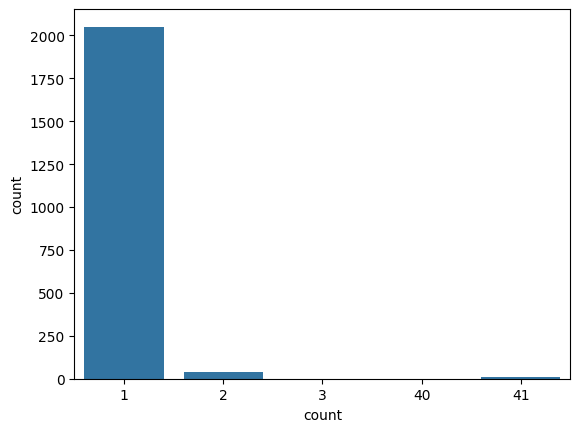

In [31]:
sns.countplot(x=success_count)